<a href="https://colab.research.google.com/github/Sebastian1657/SILaboratories/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber


In [3]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red', label='Real IBM Stock Price')
  plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-"*30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-"*30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("-"*30)
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}.".format(mape))
  print("-"*30)

In [5]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [6]:
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

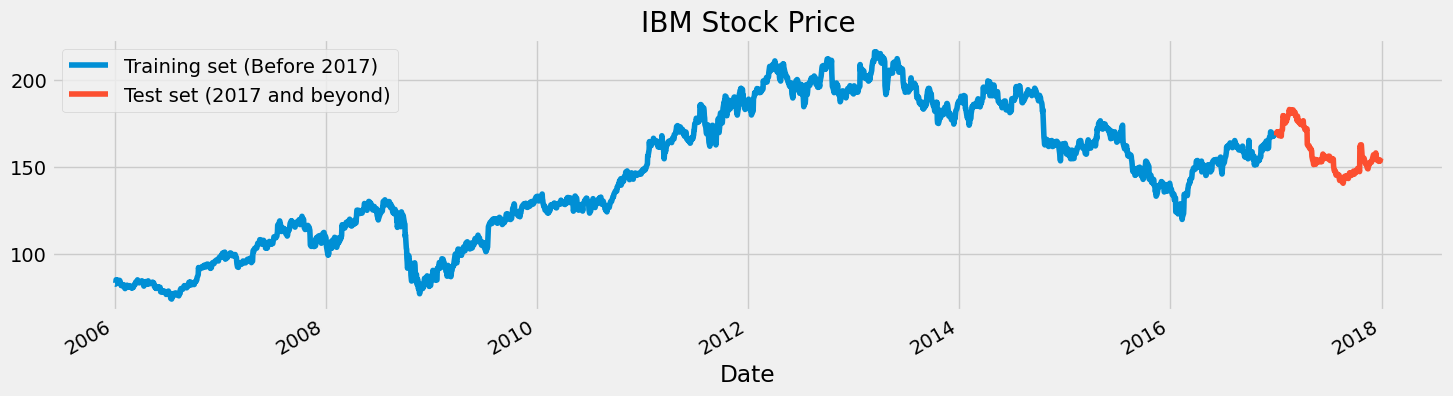

In [7]:
dataset["High"][:'2016'].plot(figsize=(16,4), legend=True)
dataset["High"]['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM Stock Price')
plt.show()

In [8]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [9]:
x_train = []
y_train = []
for i in range(60, 2769):
  x_train.append(training_set_scaled[i-60:i, 0])
  y_train.append(training_set_scaled[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [10]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Architektura LSTM

In [11]:
# Architektura LSTM, sieć regresyjna, predykcyjna
regressor = Sequential()
# Warstwa wejściowa
regressor.add(Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa LSTM
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# Warstwa wyjściowa
regressor.add(Dense(units=1))

regressor.compile(optimizer='rmsprop', loss='mean_squared_error')
#regressor.fit(x_train,y_train,epochs=50,batch_size=32)
# Wersja z Early Stopping
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressor.fit(x_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0224
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0100
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0084
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0066
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0065
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0053
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0051
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0048
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0043
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0044
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0039
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0037
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0036
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0033
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - lo

In [12]:
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [13]:
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i, 0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


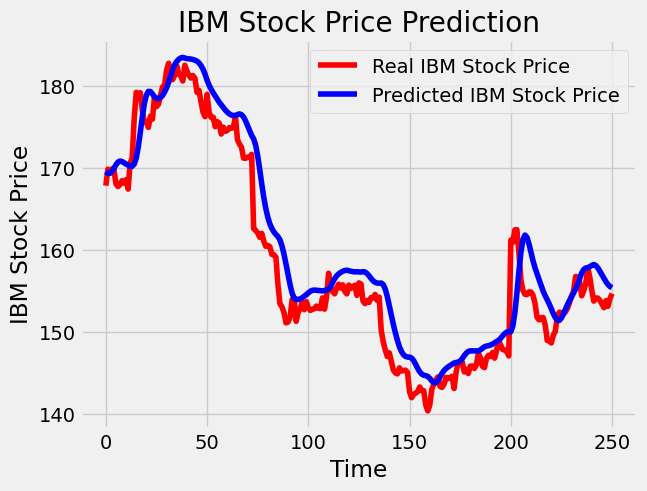

In [14]:
plot_predictions(test_set,predicted_stock_price)

In [15]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.54.
------------------------------
------------------------------
Średni błąd bezwzględny: 2.80.
Średni błąd bezwzględny procentowy: 1.77.
------------------------------


# Architektura GRU

In [16]:
regressorGRU = Sequential()
# Warstwa wejściowa
regressorGRU. add (Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa GRU z regularyzacją Dropout
regressorGRU. add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU. add(Dropout(0.2))
# Druga warstwa GRU z regularyzacją Dropout
regressorGRU. add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Trzecia warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Czwarta warstwa GRU z regularyzacją Dropout
regressorGRU. add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Warstwa wyjściowa
regressorGRU. add (Dense(units=1))

regressorGRU. compile(optimizer='rmsprop', loss='mean_squared_error')
#regressorGRU.fit(x_train,y_train,epochs=50,batch_size=32)

early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU.fit(x_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0200
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0092
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0069
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0062
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0052
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0048
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0046
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0040
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0036
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0037
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0036
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0032
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0031
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - lo

In [17]:
x_test = []
for i in range(60, 311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))
GRU_predicted_stock_price = regressorGRU.predict(x_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


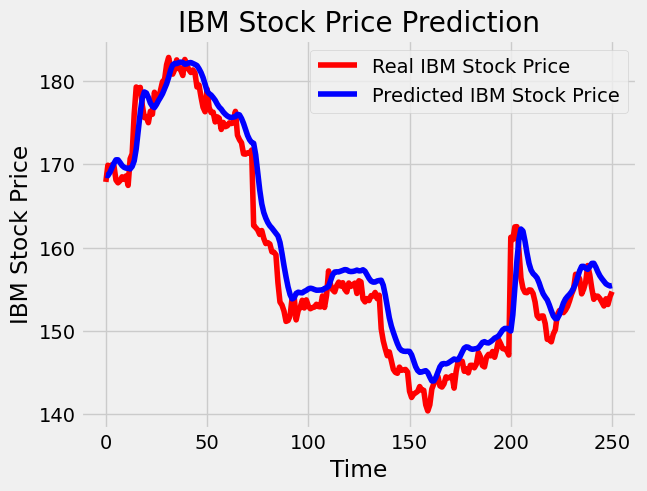

In [18]:
plot_predictions(test_set,GRU_predicted_stock_price)

In [19]:
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 3.01.
------------------------------
------------------------------
Średni błąd bezwzględny: 2.42.
Średni błąd bezwzględny procentowy: 1.55.
------------------------------


In [21]:
# Testowane parametry:
# Ilość jednostek LSTM: 50, 100, 128
# Optymizatory: SGD, RMSprop, Adam
# Funkcje straty: mean_squared_error, mean_absolute_error, Huber

training_set_close = dataset[:'2016'].iloc[:,3:4].values
test_set_close = dataset['2017':].iloc[:,3:4].values

sc_close = MinMaxScaler(feature_range=(0,1))
training_set_scaled_close = sc_close.fit_transform(training_set_close)

X_train_close = []
y_train_close = []
for i in range(60, len(training_set_scaled_close)):
    X_train_close.append(training_set_scaled_close[i-60:i, 0])
    y_train_close.append(training_set_scaled_close[i, 0])
X_train_close, y_train_close = np.array(X_train_close), np.array(y_train_close)
X_train_close = np.reshape(X_train_close, (X_train_close.shape[0], X_train_close.shape[1], 1))

In [22]:
# Najlepsza konfiguracja modelu dla predykcji:
# 4 warstwy LSTM po 100 jednostek z Dropout 0.2, optymizator Adam, funkcja straty MSE

best_regressor = Sequential()
best_regressor.add(Input(shape=(X_train_close.shape[1], 1)))

best_regressor.add(LSTM(units=100, return_sequences=True))
best_regressor.add(Dropout(0.2))

best_regressor.add(LSTM(units=100, return_sequences=True))
best_regressor.add(Dropout(0.2))

best_regressor.add(LSTM(units=100, return_sequences=True))
best_regressor.add(Dropout(0.2))

best_regressor.add(LSTM(units=100))
best_regressor.add(Dropout(0.2))

best_regressor.add(Dense(units=1))

best_regressor.compile(optimizer='adam', loss='mean_squared_error')

# Mechanizm Early Stopping
early_stop_close = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Trenowanie modelu z walidacją
best_regressor.fit(X_train_close, y_train_close, epochs=100, batch_size=32, validation_split=0.1, callbacks=[early_stop_close])


Epoch 1/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - loss: 0.0210 - val_loss: 0.0022
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0036 - val_loss: 0.0024
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 5/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 6/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0030 - val_loss: 0.0014
Epoch 7/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 8/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0029 - val_loss: 0.0012
Epoch 9/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0026 - val_loss: 0.0022
Epoch 10/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0027 - val_loss: 0.0013
Epoch 11/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0027 - val_loss: 0.0010
Epoch 12/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


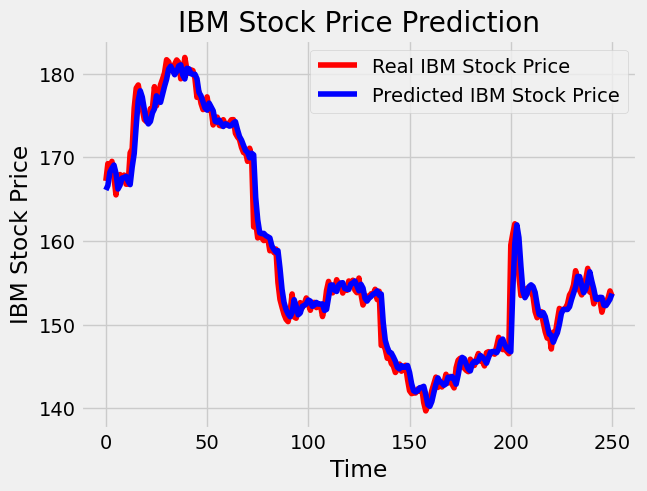

------------------------------
Błąd średniokwadratowy modelu 1.73.
------------------------------
------------------------------
Średni błąd bezwzględny: 1.11.
Średni błąd bezwzględny procentowy: 0.70.
------------------------------


In [23]:
# Przygotowanie zbioru testowego i predykcja dla atrybutu 'Close'
dataset_total_close = pd.concat((dataset['Close'][:'2016'], dataset['Close']['2017':]), axis=0)
inputs_close = dataset_total_close[len(dataset_total_close) - len(test_set_close) - 60:].values
inputs_close = inputs_close.reshape(-1,1)
inputs_close = sc_close.transform(inputs_close)

X_test_close = []
for i in range(60, len(inputs_close)):
    X_test_close.append(inputs_close[i-60:i, 0])
X_test_close = np.array(X_test_close)
X_test_close = np.reshape(X_test_close, (X_test_close.shape[0], X_test_close.shape[1], 1))

predicted_stock_price_close = best_regressor.predict(X_test_close)
predicted_stock_price_close = sc_close.inverse_transform(predicted_stock_price_close)

# Wizualizacja wyników i ocena modelu
plot_predictions(test_set_close, predicted_stock_price_close)
return_rmse(test_set_close, predicted_stock_price_close)
return_mae(test_set_close, predicted_stock_price_close)